<a href="https://colab.research.google.com/github/smorgan-blip/lis4693/blob/main/lab-4/lab_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 4: Supervised Machine Learning

In this lab assignment, we will learn to perform supervised machine learning using `sklearn` library. I would highly recommend that you go through its documentation to learn more about performing different types of ML tasks like classification, regression, clustering, model selection and dimensionality reduction here: https://scikit-learn.org/stable/


*Note: Before starting this lab assignment, please complete the Introduction to Machine Learning notebook*

## Leaning Objectives

In this exercise, you will:

- Load and process the assigned data file
- Identify `features` and `target` labels for your dataset
- Split your data into test and training sets
- Perform text-preprocessing
- Compare different classifiers' performances based on their evaluation metrics (accuracy, precision, recall, f1-score) and pick the best one for your dataset
- Visualize the confusion matrix results
- Finally, use the classifier to run on unseen (new) data to make predictions


This exercise builds directly on concepts from discussed in the precursor notebook on "Introduction to Machine Learning".

## Install and Load Libraries

In [ ]:
!pip install sklearn

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


## Load and read your file from GitHub

In [ ]:
import requests
import io

url = "https://raw.githubusercontent.com/smorgan-blip/lis4693/refs/heads/main/lab-4/lab%204%20data.csv"
response = requests.get(url)
response.raise_for_status() # Raise an exception for HTTP errors
text = response.text

Here I changed the url to link to a github csv file I made for the dataset I was tasked to use. I had to download the data from kaggle, open it in excel, save it as a csv file, and then upload it to my repository.

Let's save it as a DataFrame using `df` variable that holds pandas DataFrame and see how it looks!

As you can see, this dataset consists of metadata for journal articles published in gender and politics related journals.

In [ ]:
import pandas as pd

df = pd.read_csv(io.StringIO(text))
print(df.head())

   Class Index                                              Title  \
0            3  Wall St. Bears Claw Back Into the Black (Reuters)   
1            3  Carlyle Looks Toward Commercial Aerospace (Reu...   
2            3    Oil and Economy Cloud Stocks' Outlook (Reuters)   
3            3  Iraq Halts Oil Exports from Main Southern Pipe...   
4            3  Oil prices soar to all-time record, posing new...   

                                         Description  
0  Reuters - Short-sellers, Wall Street's dwindli...  
1  Reuters - Private investment firm Carlyle Grou...  
2  Reuters - Soaring crude prices plus worries\ab...  
3  Reuters - Authorities have halted oil export\f...  
4  AFP - Tearaway world oil prices, toppling reco...  


My dataset contains information on news articles and classifies them into four categories: world (1), sports (2), business (3), and science/tech (4).

Now, we will Split our data into **features** and **target** labels.

This dataset was part of one of my research projects, where we added a new column **"code_choice"** and the annotators manually added if the article was related to gender research or not based on the **"abstract"** for those articles.

For this dataset, as I mentioned above our features will be **Abstract** and target will be **code_choices**

In [ ]:
features = df['Title']
target = df['Class Index']

Here I chose Class Index as the target for each Title

Below, I am renaming the `code_choice` as numbers 1 or 0, where 1 states the abstract is related to gender research and 0 means the abstract is not related to gender research.

In [ ]:
target_names = {
    'world' : '1',
    'sports' : '2',
    'business' : '3',
    'sci/tech' : '4'
              }

Here I set the 4 categories of the target to the "Class Index" options World (1), Sports (2), Business (3), and Sci/Tech (4)

## Splitting Data into Training and Test Sets

Now, we will prepare our data to get ready before feeding it into any machine learning classifiers.

We will first split the data into a test dataset (20%) and a training datset (80%) randomly in 80:20 ratio followed by text-preprocessing.

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.pipeline import Pipeline

# split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=42)

# Show the results of the split
print("Training set has {} samples.".format(X_train.shape[0]))
print("Testing set has {} samples.".format(X_test.shape[0]))

# Remove or replace NaN values in X_train and X_test
X_train = X_train.fillna('')  # Replace NaN with empty string
X_test = X_test.fillna('')   # Replace NaN with empty string

preprocessing = Pipeline([
    ('vect', CountVectorizer()),
    ('tfidf', TfidfTransformer())
])

print("Preprocessing training data...")
train_preprocessed = preprocessing.fit_transform(X_train)

print("Preprocessing test data...")
test_preprocessed = preprocessing.transform(X_test)

Training set has 69999 samples.
Testing set has 30000 samples.
Preprocessing training data...
Preprocessing test data...


Here I split the dataset into a 70:30 ratio for testing and training

In [ ]:
y_test.unique()

array([2, 4, 1, 3])

## Comparing Classifiers

Now, we will run 5 different classifiers (Naive Bayes, Logistic Regression, Support Vector Machine, AdaBoost, Random Forest) on our dataset and see which one performs best based on the evaluation metrics (accuracy, recall, precision, f1 score)

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

nb_classifier = MultinomialNB()
svm_classifier = LinearSVC()
random_classifier = RandomForestClassifier()

print("Training Naive Bayes classifier...")
nb_classifier.fit(train_preprocessed, y_train)

print("Training SVM classifier...")
svm_classifier.fit(train_preprocessed, y_train)

print("Training Random Forest classifier...")
random_classifier.fit(train_preprocessed, y_train)

Training Naive Bayes classifier...
Training SVM classifier...
Training Random Forest classifier...


RandomForestClassifier()

In [ ]:
nb_predictions = nb_classifier.predict(test_preprocessed)
svm_predictions = svm_classifier.predict(test_preprocessed)
random_predictions = random_classifier.predict(test_preprocessed)

In [ ]:
import numpy as np

print("NB Accuracy:", np.mean(nb_predictions == y_test))
print("SVM Accuracy:", np.mean(svm_predictions == y_test))
print("RF Accuracy:", np.mean(random_predictions == y_test))

NB Accuracy: 0.8578666666666667
SVM Accuracy: 0.8667333333333334
RF Accuracy: 0.7988666666666666


Here I ran the classifiers Naive Bayes, Linear SVC, and Random Forest because they all predicted class labels. It looks like Linear SVC just barely had the highest accuracy of 0.86673 where Naive Bayes had second with 0.85786. Accuracy isn't the only factor for deciding the best classifier but with large datasets I think it is very important. Looking deeper into what you are sacrificing if you go with one that isn't the best in all other categories could influence your decision if you take the risk.

The results above indicate that the ADA classifier performed best, achieving an accuracy of 91%. However, accuracy alone should not be the sole criterion for selecting a classifier. Other evaluation metrics, such as precision, recall, and F1-score, should also be considered to obtain a more comprehensive assessment of model performance.

Now, we will run the classification report for all 5 classifiers.

In [ ]:
from sklearn.metrics import classification_report  # Import classification_report

print(classification_report(y_test, nb_predictions, target_names=target_names))
print(classification_report(y_test, random_predictions, target_names=target_names))


              precision    recall  f1-score   support

       world       0.86      0.87      0.86      7471
      sports       0.90      0.92      0.91      7444
    business       0.84      0.82      0.83      7490
    sci/tech       0.84      0.83      0.84      7595

    accuracy                           0.86     30000
   macro avg       0.86      0.86      0.86     30000
weighted avg       0.86      0.86      0.86     30000

              precision    recall  f1-score   support

       world       0.86      0.80      0.83      7471
      sports       0.72      0.91      0.80      7444
    business       0.82      0.74      0.78      7490
    sci/tech       0.83      0.75      0.79      7595

    accuracy                           0.80     30000
   macro avg       0.81      0.80      0.80     30000
weighted avg       0.81      0.80      0.80     30000



Here I ran the classification reports for Naive Bayes and Random Forest. It looks like Naive Bayes did significantly better than Random Forest in precision, recall, and f-1 making it a better choice.

The code from line 51-54 runs the classification report for Support Vactor Machine classifier.

In [ ]:
from sklearn.model_selection import GridSearchCV

parameters = {'C': np.logspace(0, 3, 10)}
parameters = {'C': [0.1, 1, 10, 100, 1000]}

print("Grid search for SVM")
svm_best = GridSearchCV(svm_classifier, parameters, cv=10, verbose=1)
svm_best.fit(train_preprocessed, y_train)

Grid search for SVM
Fitting 10 folds for each of 5 candidates, totalling 50 fits


GridSearchCV(cv=10, estimator=LinearSVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000]}, verbose=1)

In [ ]:
print("Best SVM Parameters")
print(svm_best.best_params_)

Best SVM Parameters
{'C': 1}


In [ ]:
best_svm_predictions = svm_best.predict(test_preprocessed)

print("Best SVM Accuracy:", np.mean(best_svm_predictions == y_test))

Best SVM Accuracy: 0.8667333333333334


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, svm_predictions, target_names=target_names))

              precision    recall  f1-score   support

       world       0.89      0.86      0.88      7471
      sports       0.89      0.93      0.91      7444
    business       0.84      0.83      0.83      7490
    sci/tech       0.85      0.84      0.85      7595

    accuracy                           0.87     30000
   macro avg       0.87      0.87      0.87     30000
weighted avg       0.87      0.87      0.87     30000



Here we ran the Linear SVC report and it looks like it did slightly better than Random Forest in precision, recall, and f-1 making it the better choice overall because it was weren't sacrificing the best performance of any criteria in this decision.

Again, based on all the classification report for all the evaluation metrics across precision, recall, accuracy, and f1 score, AdaBoost performed the best!

Now, we will visualize the confusion matrix using the AdaBoost classifier.

(array([0.5, 1.5, 2.5, 3.5]),
 [Text(0.5, 0, 'world'),
  Text(1.5, 0, 'sports'),
  Text(2.5, 0, 'business'),
  Text(3.5, 0, 'sci/tech')])

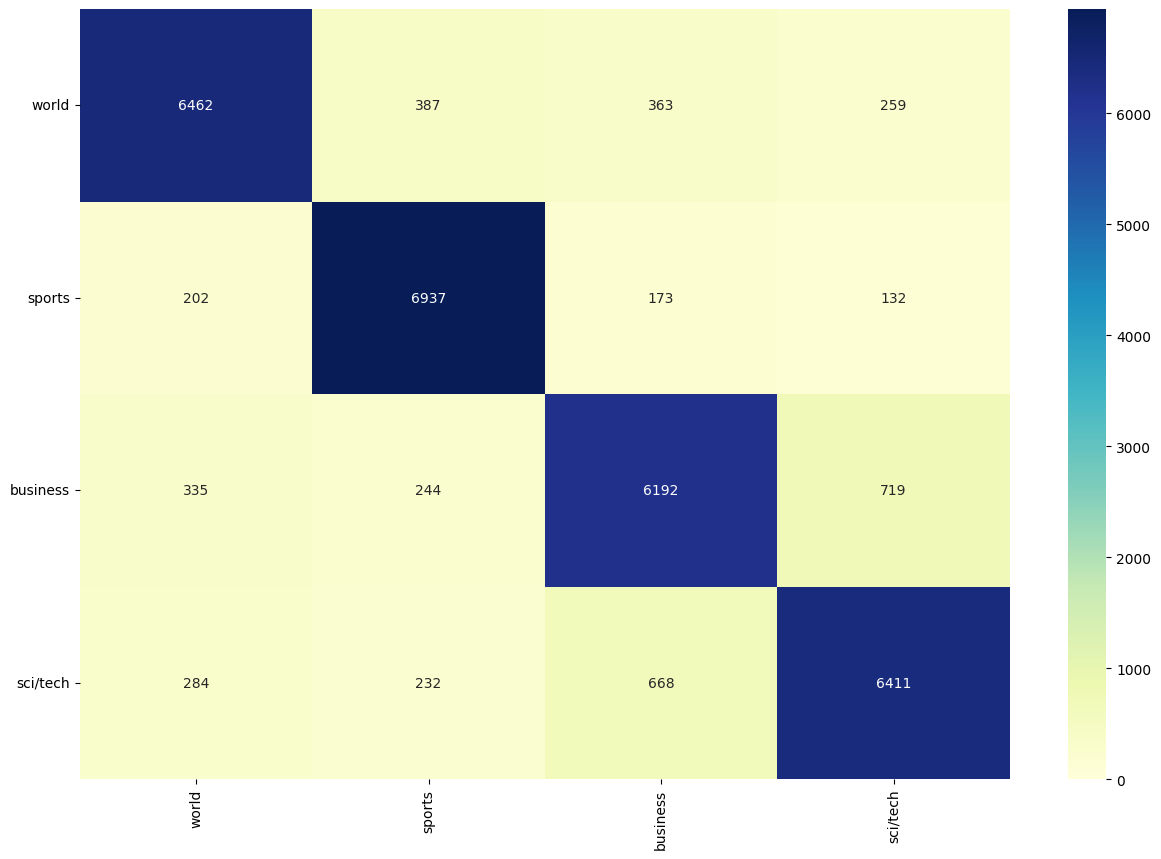

In [ ]:
%matplotlib inline
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt

conf_matrix = confusion_matrix(y_test, svm_predictions)
conf_matrix_df = pd.DataFrame(conf_matrix, index=target_names, columns=target_names)

plt.figure(figsize=(15, 10))
x = sn.heatmap(conf_matrix_df, annot=True, vmin=0, vmax=conf_matrix.max(), fmt='d', cmap="YlGnBu")
plt.yticks(rotation=0)
plt.xticks(rotation=90)

Here I made the confusion matrix for the best performing classifer with my dataset, Linear SVC.

The confusion matrix shows the number of abstracts that AdaBoost correctly and incorrectly classified as gendered and non-gendered research. For example, the model correctly classified 302 abstracts as gendered but incorrectly labeled 60 abstracts as gendered when they were actually non-gendered. Similarly, the model correctly classified 600 abstracts as non-gendered, while misclassifying 25 abstracts as non-gendered when they were in fact gendered.

## Supervised Machine Learning

Now, we will use the machine learning model that selected with AdaBoost Classifier to run on the data it has never seen to make predictions aka Supervised Machine Learning!

For this task, we will now upload new dataset with empty "code_choice" column.

In [ ]:
url = "https://raw.githubusercontent.com/manika-lamba/SP26-LIS4_5693/refs/heads/main/lab-assignments/lab-4/new-data.csv"
response = requests.get(url)
response.raise_for_status() # Raise an exception for HTTP errors
raw_csv_data = response.text # Store the raw CSV string

new_data = pd.read_csv(io.StringIO(raw_csv_data))
print(new_data.head())

                                              AU   DE  \
0                      BARNETT C;A. J A;MONROE S  NaN   
1                DANCEY L;HENDERSON J;SHEAGLEY G  NaN   
2                      SHOUB K;STAUFFER K;SONG M  NaN   
3  DANCYGIER R;EGAMI N;JAMAL A;RISCHKE ;RAMONA R  NaN   
4                   CHOI D;POERTNER M;SAMBANIS N  NaN   

                                                  ID  \
0  GENDER; EMPLOYMENT; WORK; PARTICIPATION; DECIS...   
1  SOCIAL CONSTRUCTION; INCUMBENCY; ADVANTAGE; PA...   
2  REPRESENTATIVE BUREAUCRACY; UNDOING GENDER; PE...   
3                                                NaN   
4  IMPLICIT ASSOCIATION TEST; INTERGROUP CONTACT;...   

                                                  C1  \
0  BARNETT, C (CORRESPONDING AUTHOR), PRINCETON U...   
1  DANCEY, L (CORRESPONDING AUTHOR), WESLEYAN UNI...   
2  SHOUB, K (CORRESPONDING AUTHOR), UNIV SOUTH CA...   
3  DANCYGIER, R (CORRESPONDING AUTHOR), PRINCETON...   
4  CHOI, DD (CORRESPONDING AUTHOR), UNIV

In [ ]:
text = new_data['AB']

In [ ]:
text

,AB
0,DOES EARNING INCOME EMPOWER WOMEN IN PATRIARCH...
1,THIS STUDY OFFERS EXPERIMENTAL TESTS OF THE ``...
2,POLITICAL SCIENTISTS HAVE INCREASINGLY BEGUN T...
3,AS THE NUMBER OF REFUGEES RISES ACROSS THE WOR...
4,WHY DO NATIVE EUROPEANS DISCRIMINATE AGAINST M...
...,...
1474,"IN AN ERA OF INCREASINGLY PUBLIC DIPLOMACY, CO..."
1475,THIS ARTICLE INVESTIGATES HOW UNEMPLOYMENT RIS...
1476,POLICIES TO ADDRESS RECONCILIATION OF WORK AND...
1477,HOW DO AUTHORITARIAN STATES IMPLEMENT POLICIES...


Now, we will do text-preprocessing.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
vect = TfidfVectorizer(stop_words = 'english').fit(X_train)
dtm = vect.fit_transform(X_train)

## Predicting Features: Fitting New Dataset

Using the code below, we will use the AdaBoost Classifier to make predictions based on our previously trained machine learning model.

Here the `fit()` method trains the AdaBoost Classifier model using our training data:

- `dtm` represents the preprocessed training features. It's likely a Document-Term Matrix (DTM) or TF-IDF matrix generated from the text abstracts (X_train) during the text preprocessing steps.
- `y_train` is the corresponding target labels (e.g., 0 or 1 for 'non-gendered' or 'gendered' research) for each sample in dtm.

After this line executes, classifier holds the trained machine learning model, ready to make predictions.

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
model = AdaBoostClassifier()
classif = model.fit(dtm, y_train)

The next line of code preprocesses the 'Abstract' column (AB) from the `new_data` DataFrame so that it's in the same format as the data the model was trained on.

In [ ]:
test_dtm = vect.transform(new_data['AB'])

Removing any empty values for abstracts

In [ ]:
import pandas as pd

# Replace NaN values with an empty string before applying transform
new_data['AB'] = new_data['AB'].fillna('')
test_dtm = vect.transform(new_data['AB'])

Using the code below, we are making predictions using our machine learning model for the `code_choice` in our new dataset.

In [ ]:
test = classif.predict(test_dtm)

Here, I am renaming the column from 0 -> code_choice.

In [ ]:
df2 = pd.DataFrame(test)
df2.rename(columns={0: 'code_choice'}, inplace=True)

In [ ]:
df2

,code_choice
0,1
1,0
2,1
3,1
4,1
...,...
1474,0
1475,0
1476,1
1477,0


You can see from above results that we have now successfully tagged each article based on the abstract as 1 (gendered) or 0 (non-gendered)!!

Let’s merge the metadata from the new_data file with the `code_choice` column from df2 into the original file that contains the empty column. This will allow us to reconstruct the complete dataset, which can then be shared with others or used for downstream analysis and processing.

In [ ]:
new_data['code_choice'] = df2['code_choice']
combined_df = new_data

In [ ]:
display(combined_df.head())

,AU,DE,ID,C1,CR,AB,DI,SN,JI,SO,...,AU_UN_NR,SR_FULL,SR,UID,gender_journ,auto_abs,code_choice,Abbreviation,Association,Year Founded
0,BARNETT C;A. J A;MONROE S,NaN,GENDER; EMPLOYMENT; WORK; PARTICIPATION; DECIS...,"BARNETT, C (CORRESPONDING AUTHOR), PRINCETON U...","AKTER S., 2005, JOURNAL OF DEVELOPING AREAS, V...",DOES EARNING INCOME EMPOWER WOMEN IN PATRIARCH...,10.1111/AJPS.12561,0092-5853,AM. J. POLIT. SCI.,AMERICAN JOURNAL OF POLITICAL SCIENCE,...,NaN,"BARNETT C, 2021,","BARNETT C, 2021,",9329,0,0,1,AJPS,MPSA,1957
1,DANCEY L;HENDERSON J;SHEAGLEY G,NaN,SOCIAL CONSTRUCTION; INCUMBENCY; ADVANTAGE; PA...,"DANCEY, L (CORRESPONDING AUTHOR), WESLEYAN UNI...","ABRAMOWITZ AI, 2016, ELECT STUD, V41, P12, DOI...",THIS STUDY OFFERS EXPERIMENTAL TESTS OF THE ``...,10.1111/AJPS.12815,0092-5853,AM. J. POLIT. SCI.,AMERICAN JOURNAL OF POLITICAL SCIENCE,...,NaN,"DANCEY L, 2023,","DANCEY L, 2023,",9330,0,0,0,AJPS,MPSA,1957
2,SHOUB K;STAUFFER K;SONG M,NaN,REPRESENTATIVE BUREAUCRACY; UNDOING GENDER; PE...,"SHOUB, K (CORRESPONDING AUTHOR), UNIV SOUTH CA...","ANONYMOUS, 2010, CRIM DAT BRIEF WOM L; BAUMGAR...",POLITICAL SCIENTISTS HAVE INCREASINGLY BEGUN T...,10.1111/AJPS.12618,0092-5853,AM. J. POLIT. SCI.,AMERICAN JOURNAL OF POLITICAL SCIENCE,...,NaN,"SHOUB K, 2021,","SHOUB K, 2021,",9331,0,0,1,AJPS,MPSA,1957
3,DANCYGIER R;EGAMI N;JAMAL A;RISCHKE ;RAMONA R,NaN,NaN,"DANCYGIER, R (CORRESPONDING AUTHOR), PRINCETON...","ADIDA CL, 2014, IMMIGRANT EXCLUSION AND INSECU...",AS THE NUMBER OF REFUGEES RISES ACROSS THE WOR...,10.1111/AJPS.12595,0092-5853,AM. J. POLIT. SCI.,AMERICAN JOURNAL OF POLITICAL SCIENCE,...,NaN,"DANCYGIER R, 2022,","DANCYGIER R, 2022,",9333,0,0,1,AJPS,MPSA,1957
4,CHOI D;POERTNER M;SAMBANIS N,NaN,IMPLICIT ASSOCIATION TEST; INTERGROUP CONTACT;...,"CHOI, DD (CORRESPONDING AUTHOR), UNIV PITTSBUR...","ADIDA CL, 2010, P NATL ACAD SCI USA, V107, P22...",WHY DO NATIVE EUROPEANS DISCRIMINATE AGAINST M...,10.1111/AJPS.12627,0092-5853,AM. J. POLIT. SCI.,AMERICAN JOURNAL OF POLITICAL SCIENCE,...,NaN,"CHOI D, 2023,","CHOI D, 2023,",9334,0,0,1,AJPS,MPSA,1957


Let's SAVE the combined data as a CSV file.

In [ ]:
combined_df.to_csv('predicted_data.csv', index=False)